Paquetes necesarios

In [1]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt

**TAREA**: Sin herramientas de IA, crea una imagen, p.e. de 800x800 píxeles, con la textura del tablero de ajedrez.
Una vez resuelto de forma manual, resuelve la misma tarea usando un asistente de IA de tu elección (Claude, ChatGPT, Copilot, etc.). Compara ambas versiones en el informe de la práctica.

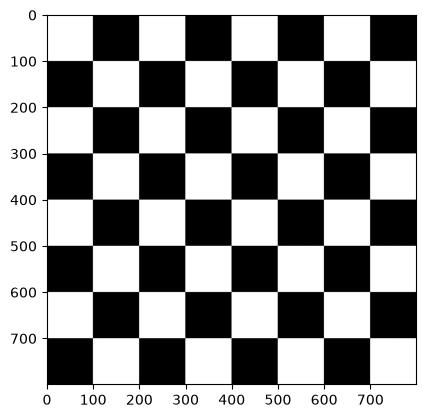

In [3]:
width = 800
height = 800
block_size = width // 8

board = np.zeros((height,width,1), dtype = np.uint8)

for i in range(0, 8):
    for j in range(0, 8):
        if (i + j) % 2 == 0:
            board[i*block_size:i*block_size + block_size, j*block_size: j*block_size + block_size] = 255


plt.imshow(board, cmap='gray',vmin=0, vmax=255)
plt.show()

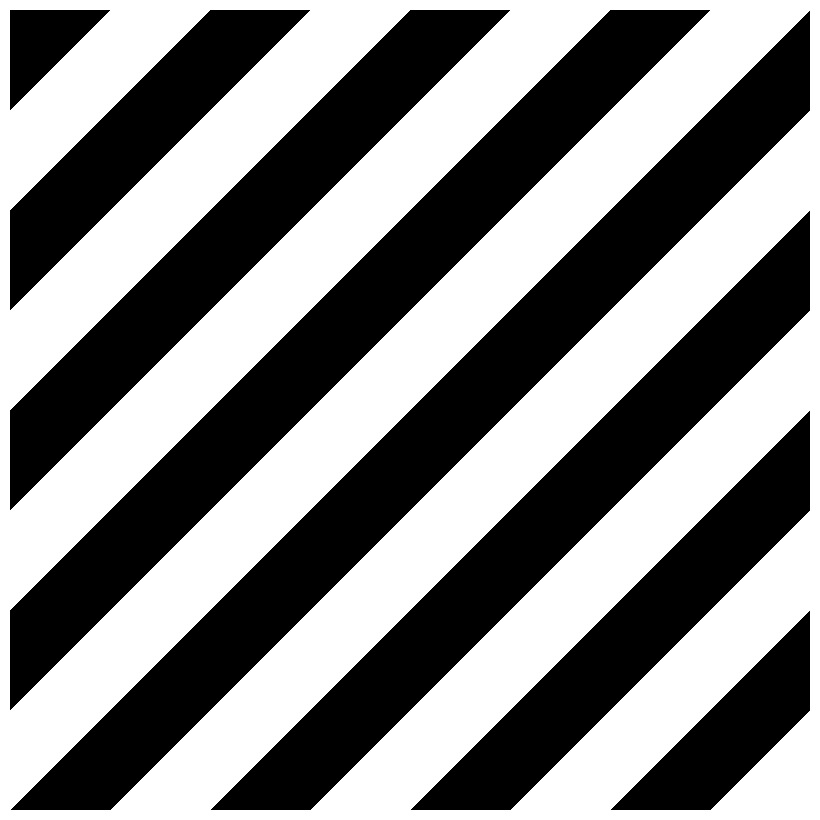

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Tamaño de la imagen
N = 800

# Número de casillas
casillas = 8

# Crear una cuadrícula de 800x800
tablero = np.indices((N, N)).sum(axis=0) // (N // casillas)

# Alternar colores de las casillas
tablero = tablero % 2

# Crear la figura exactamente de 800x800 píxeles
fig, ax = plt.subplots(figsize=(8, 8), dpi=100)

# Mostrar el tablero
ax.imshow(tablero, cmap="gray", vmin=0, vmax=1)

# Quitar ejes
ax.axis("off")

# Ajustar para que no haya márgenes
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

# Guardar como imagen PNG de 800x800
plt.savefig("tablero_ajedrez.png", dpi=100, bbox_inches="tight", pad_inches=0)

# Mostrar
plt.show()


**TAREA**: Crear una imagen estilo Mondrian (un ejemplo https://www3.gobiernodecanarias.org/medusa/ecoescuela/sa/2017/04/17/descubriendo-a-mondrian/) con las funciones de dibujo de OpenCV.
No hagas uso de herramientas de IA, parte del ejemplo anterior.

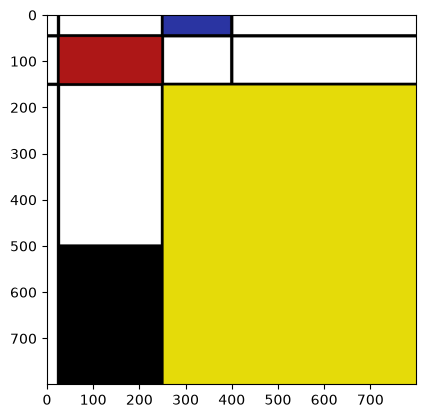

True

In [ ]:
width = 800
height = 800

mondrian = np.zeros((height,width,3), dtype = np.uint8)
mondrian[:,:,:] = 255

# Lineas verticales
cv2.line(mondrian, (int(width/2), 0), (int(width/2), height), (0, 0, 0), 5)
cv2.line(mondrian, (25, 0), (25, height), (0, 0, 0), 5)
cv2.line(mondrian, (250, 0), (250, height), (0, 0, 0), 5)

# Lineas horizontales
cv2.line(mondrian, (0, 45), (width, 45), (0, 0, 0), 5)
cv2.line(mondrian, (0, 150), (width, 150), (0, 0, 0), 5)
cv2.line(mondrian, (25, 500), (250, 500), (0, 0, 0), 5)


#Rectángulos
cv2.rectangle(mondrian,(28,48),(247, 147),(173,23,23), -1)
cv2.rectangle(mondrian,(253,153),(width, height),(229,219,9), -1)
cv2.rectangle(mondrian,(253,0),(396, 41),(42,52,162), -1)
cv2.rectangle(mondrian,(25,503),(250, height),(0,0,0), -1)

plt.imshow(mondrian) 
plt.show()

#Salva la imagen resultante a disco
cv2.imwrite('mondrian.jpg', mondrian)

**TAREA**:
Pintar círculos en las posiciones del píxel más claro y oscuro de cada fotograma captado por la cámara. ¿Funciona de forma fluida o a saltos? En el segundo caso, ¿podrías acelerarlo?
Si haces uso de herramientas de IA, incluye la conversación.


In [29]:
vid = cv2.VideoCapture(0)

#Dimensiones de la cámara
w = int(vid.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(vid.get(cv2.CAP_PROP_FRAME_HEIGHT))

fn = 999
while True:

    ret, frame = vid.read()
    if not ret:
        continue

    fn += 1
    if fn > 20:
        fn = 0
        max_pixel = 0
        max_pixel_pos = (0, 0)
        min_pixel = 765
        min_pixel_pos = (0, 0)
        for i in range(0, h):
            for j in range(0, w):
                value = int(frame[i, j, 0]) + int(frame[i, j, 1]) + int(frame[i, j, 2])
                if value > max_pixel:
                    max_pixel = value
                    max_pixel_pos = (j, i)
                if value < min_pixel:
                    min_pixel = value
                    min_pixel_pos = (j, i)

    cv2.circle(frame, min_pixel_pos, 10, (255,0,0), 1)
    cv2.circle(frame, max_pixel_pos, 10, (0,0,255), 1)
    cv2.imshow('Cam', frame)

        # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break

# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()


TAREA: Llevar a cabo una propuesta propia de pop art.
Incluye fuentes consultadas. 
Si haces uso de herramientas de IA, incluye la conversación.

In [6]:
# https://stackoverflow.com/questions/5906693/how-to-reduce-the-number-of-colors-in-an-image-with-opencv

vid = cv2.VideoCapture(0)

#Dimensiones de la cámara
w = int(vid.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(vid.get(cv2.CAP_PROP_FRAME_HEIGHT))

#Fuerzo a mitad de resolución para ocupar menos pantalla
w=int(w/3)
h=int(h/3)
vid.set(cv2.CAP_PROP_FRAME_WIDTH, w) #En Mac no reacciona a estos comandos
vid.set(cv2.CAP_PROP_FRAME_HEIGHT, h)

#Imagen conjunta 2x original
collage = np.zeros((h*3,w*3,3), dtype = np.uint8)
tl = collage[0:h,0:w]
tm = collage[0:h,w:w+w]
tr = collage[0:h,w+w:w+w+w]

ml = collage[h:h+h,0:w]
mm = collage[h:h+h,w:w+w]
mr = collage[h:h+h,w+w:w+w+w]

bl = collage[h+h:h+h+h,0:w]
bm = collage[h+h:h+h+h, w:w+w]
br = collage[h+h:h+h+h,w+w:w+w+w]


while True:      
    # fotograma a fotograma
    ret, frameIN = vid.read()

    #Menor tamaño
    frame = cv2.resize(frameIN, (int(w),int(h)),cv2.INTER_NEAREST)
    div = 100
    frame = frame // div * div + div // 2
    if ret:
        r = frame[:,:,2]
        g = frame[:,:,1]
        b = frame[:,:,0]
        tl[:,:,0] = b 
        tl[:,:,1] = g
        tl[:,:,2] = r

        tm[:,:,0] = b
        tm[:,:,1] = 255 - g 
        tm[:,:,2] = r 

        tr[:,:,0] = 255 - b
        tr[:,:,1] = g
        tr[:,:,2] = r

        ml[:,:,0] = b
        ml[:,:,1] = g
        ml[:,:,2] = 255 - r

        mm[:,:,0] = 255 - b
        mm[:,:,1] = 255 - g
        mm[:,:,2] = 255 - r

        mr[:,:,0] = g
        mr[:,:,1] = r 
        mr[:,:,2] = b

        bl[:,:,0] = b - 40
        bl[:,:,1] = 85
        bl[:,:,2] = r 


        bm[:,:,0] = r
        bm[:,:,1] = b - 50
        bm[:,:,2] = g

        br[:,:,0] = b
        br[:,:,1] = g
        br[:,:,2] = r
    
        # Muestra composición
        
        cv2.imshow('Cam', collage)
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()